# Introduzione a Pandas

In [1]:
#!pip install pandas

In [2]:
import pandas as pd

## Struttura dati principale

La libreria `pandas` introduce due nuove strutture dati: `Series` e `DataFrame`.

### La series di Pandas

Una Series è un oggetto unidimensionale (simile a un array, a una lista o a una colonna in una tabella). A ciascun elemento della Series viene assegnato un indice etichettato (i predefiniti sono gli indici da 0 a N, dove N è la lunghezza della Series meno uno).

In [3]:
# Creo una serie partendo da una lista di valori
s = pd.Series([7, "Hello world", 42.26, True, "Falsissimo"])

print(f"Serie con indice di default: \n{s}")

Serie con indice di default: 
0              7
1    Hello world
2          42.26
3           True
4     Falsissimo
dtype: object


In [4]:
# Creo una series con un indice definito da me
series_with_index = pd.Series([2, True, "Hey", 3.14], index=["A", "B", "C", "Ciao"])

print(f"\nSeries con indice personalizzato: \n{series_with_index}")


Series con indice personalizzato: 
A          2
B       True
C        Hey
Ciao    3.14
dtype: object


In [5]:
# Operazioni algebriche
s = pd.Series([1, 2, 3], index=["A", "B", "C"])

print(f"\ns + 10: \n{s + 10}")
print(f"\ns*2: \n{s*2}")


s + 10: 
A    11
B    12
C    13
dtype: int64

s*2: 
A    2
B    4
C    6
dtype: int64


In [6]:
s = pd.Series([1, 2, 3], index=["A", "B", "C"])

# Accedo a una series indicizzata
print(f"Elemento all'indice 'A' di s: {s['A']}")
print(f"Elemento all'indice 'Ciao': {series_with_index['Ciao']}")

# Accedo a più elementi contemporaneamente
intreresting_elements = ["A", "B"]
print(f"Elementi di interesse di s \n{s[intreresting_elements]}")

Elemento all'indice 'A' di s: 1
Elemento all'indice 'Ciao': 3.14
Elementi di interesse di s 
A    1
B    2
dtype: int64


In [7]:
# Eseguo operazioni di riduzione (somma, media, massimo, ecc...)
s = pd.Series([1, 2, 3], index=["A", "B", "C"])

s.sum()

np.int64(6)

In [8]:
# Posso anche costruire una series partendo da un dizionario. In tal caso l'indice corrisponderà alla chiave. 
cities = {
    "Chicago": 1000,
    "New York": 1300,
    "Portland": 900,
    "San Francisco": 1100,
    "Austin": 450,
    "Boston": None,
}
cities = pd.Series(cities)

print(f"\nSeries delle città: \n{cities}")


Series delle città: 
Chicago          1000.0
New York         1300.0
Portland          900.0
San Francisco    1100.0
Austin            450.0
Boston              NaN
dtype: float64


In [9]:
# Come in R, posso lavorare con le maschere booleane
cities > 0

Chicago           True
New York          True
Portland          True
San Francisco     True
Austin            True
Boston           False
dtype: bool

In [10]:
cities[cities > 1000]

New York         1300.0
San Francisco    1100.0
dtype: float64

## I Dataframe di Pandas

Un `DataFrame` è una struttura dati tabulare composta da righe e colonne. Posso pensarlo come un gruppo di oggetti Series che condividono un indice (il nome delle colonne).

Per creare manualmente un DataFrame posso passare un dizionario di liste al costruttore del DataFrame:

In [11]:
data = {
    "letters": ["A", "B", "C", "D"],
    "numbers": [1, 2, 3, 4],
    "spelling": ["One", "Two", "Three", "Four"],
}

letters_numbers = pd.DataFrame(data, columns=["letters", "numbers", "spelling"])
print(letters_numbers)

  letters  numbers spelling
0       A        1      One
1       B        2      Two
2       C        3    Three
3       D        4     Four


Molto spesso ho a disposizione un dataset che voglio caricare in un DataFrame. Con pandas è possibile caricare dati memorizzati in moltissimi formati, ma il più comune è probabilmente il CSV. Posso usare la funzione read_csv per farlo, passandole il percorso del file (funziona anche con i link alle risorse web!).

In [12]:
# Importo il dataset csv
path_csv = "https://raw.githubusercontent.com/LorenzoTonet/Intro_to_ML_26-27/refs/heads/main/data/ign.csv"
#path_csv = "percorso del file locale"
reviews = pd.read_csv(path_csv, index_col=0)
reviews.head(5)

,score_phrase,title,url,platform,score,genre,editors_choice,release_year,release_month,release_day
0,Amazing,LittleBigPlanet PS Vita,/games/littlebigplanet-vita/vita-98907,PlayStation Vita,9.0,Platformer,Y,2012,9,12
1,Amazing,LittleBigPlanet PS Vita -- Marvel Super Hero E...,/games/littlebigplanet-ps-vita-marvel-super-he...,PlayStation Vita,9.0,Platformer,Y,2012,9,12
2,Great,Splice: Tree of Life,/games/splice/ipad-141070,iPad,8.5,Puzzle,N,2012,9,12
3,Great,NHL 13,/games/nhl-13/xbox-360-128182,Xbox 360,8.5,Sports,N,2012,9,11
4,Great,NHL 13,/games/nhl-13/ps3-128181,PlayStation 3,8.5,Sports,N,2012,9,11


### Indicizzazione (Indexing)

`pandas` supporta diversi metodi per indicizzare i dati all'interno di una tabella:
- `iloc` (indicizzazione basata su interi): mi permette di riferirmi a righe e colonne tramite la loro posizione, espressa come un intero a partire da zero;
- `loc` (indicizzazione basata su etichette): usa i nomi delle righe e delle colonne;
- Indicizzazione booleana: usa le maschere booleane. I nomi delle righe sono memorizzati nel campo index di un data frame, i nomi delle colonne sono memorizzati nel campo columns.

In [13]:
# Seleziono un sottoinsieme di righe e colonne del dataframe
print(reviews.iloc[0:10, 0:2])  # prime dieci righe, prime due colonne (L'ULTIMO INDICE NON È INCLUSO)

  score_phrase                                              title
0      Amazing                            LittleBigPlanet PS Vita
1      Amazing  LittleBigPlanet PS Vita -- Marvel Super Hero E...
2        Great                               Splice: Tree of Life
3        Great                                             NHL 13
4        Great                                             NHL 13
5         Good                          Total War Battles: Shogun
6        Awful                                Double Dragon: Neon
7      Amazing                                       Guild Wars 2
8        Awful                                Double Dragon: Neon
9         Good                          Total War Battles: Shogun


In [14]:
# Seleziono un sottoinsieme di righe e colonne usando i nomi delle colonne
reviews.loc[0:10, ["title", "score"]]

,title,score
0,LittleBigPlanet PS Vita,9.0
1,LittleBigPlanet PS Vita -- Marvel Super Hero E...,9.0
2,Splice: Tree of Life,8.5
3,NHL 13,8.5
4,NHL 13,8.5
5,Total War Battles: Shogun,7.0
6,Double Dragon: Neon,3.0
7,Guild Wars 2,9.0
8,Double Dragon: Neon,3.0
9,Total War Battles: Shogun,7.0


In [15]:
# Estraggo una Series da un DataFrame
scores = reviews["score"]
print(scores)
type(scores)

0         9.0
1         9.0
2         8.5
3         8.5
4         8.5
         ... 
18620     7.6
18621     9.0
18622     5.8
18623    10.0
18624    10.0
Name: score, Length: 18625, dtype: float64


pandas.Series

In [16]:
# Indicizzazione tramite maschere booleane
mask = reviews["score"] >= 9.5

# Recupero il titolo dei giochi con un punteggio >= 9.5
cool_games = reviews[mask]["title"]
print(cool_games)

33                   Pokemon White Version 2
35                   Pokemon Black Version 2
52       The World Ends with You: Solo Remix
54       The World Ends with You: Solo Remix
135        Zero Escape: Virtue's Last Reward
                        ...                 
18511                                 Inside
18562                Odin Sphere Leifthrasir
18563                Odin Sphere Leifthrasir
18623                                 Inside
18624                                 Inside
Name: title, Length: 385, dtype: str


## Alcune Visualizzazioni

In [17]:
#!pip install matplotlib

In [18]:
import matplotlib.pyplot as plt

Text(0, 0.5, 'Frequenza')

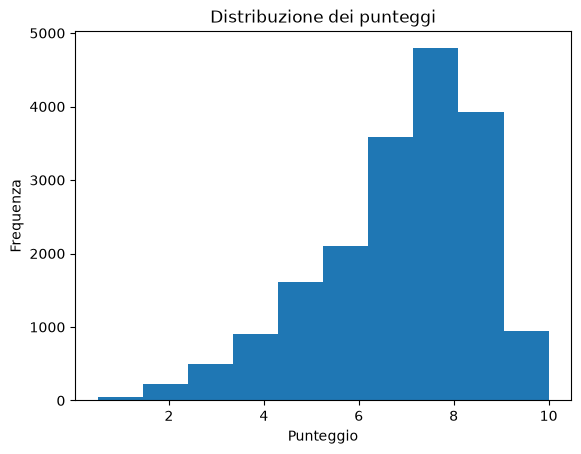

In [19]:
# Istogramma
plt.title('Distribuzione dei punteggi')
_ = plt.hist(reviews["score"])
plt.xlabel('Punteggio')
plt.ylabel('Frequenza')

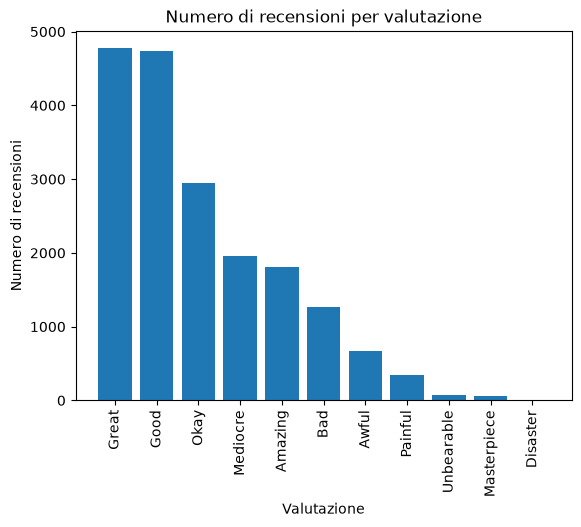

In [20]:
counts_per_genre = reviews['score_phrase'].value_counts()
plt.bar(counts_per_genre.index, counts_per_genre)
plt.xticks(rotation=90)

# Aggiungo il titolo e le etichette degli assi
plt.title('Numero di recensioni per valutazione')
plt.xlabel('Valutazione')
_ = plt.ylabel('Numero di recensioni')

Giusto per curiosità...

In [21]:
mask = reviews["score_phrase"] == "Disaster"
reviews[mask]

,score_phrase,title,url,platform,score,genre,editors_choice,release_year,release_month,release_day
890,Disaster,Extreme PaintBrawl,/games/extreme-paintbrawl/pc-10455,PC,0.7,Action,N,1998,10,29
5242,Disaster,Looney Tunes: Back in Action: Zany Race,/games/looney-tunes-back-in-action-zany-race/c...,Wireless,0.5,Racing,N,2003,10,28
12513,Disaster,Action Girlz Racing,/games/action-girlz-racing/wii-889218,Wii,0.8,Racing,N,2009,2,11


---

Se voglio approfondire ulteriormente le mie conoscenze su **Pandas**, posso dare un'occhiata a [questo link](https://it.wikipedia.org/wiki/Ailuropoda_melanoleuca) *(sì, è un panda vero!)* o consultare la [documentazione ufficiale](https://pandas.pydata.org/docs/).


---